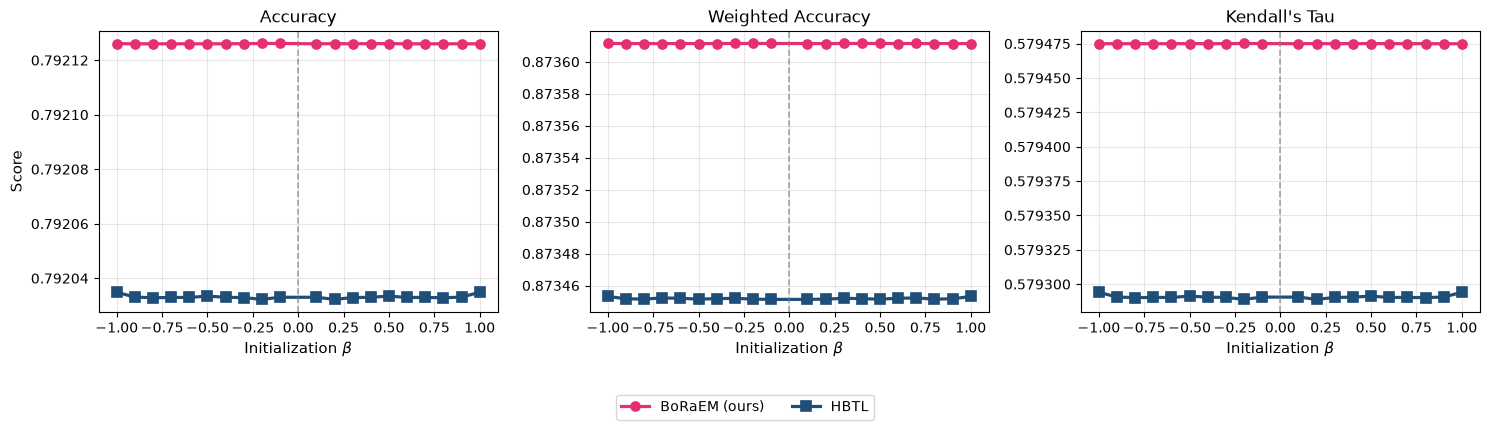

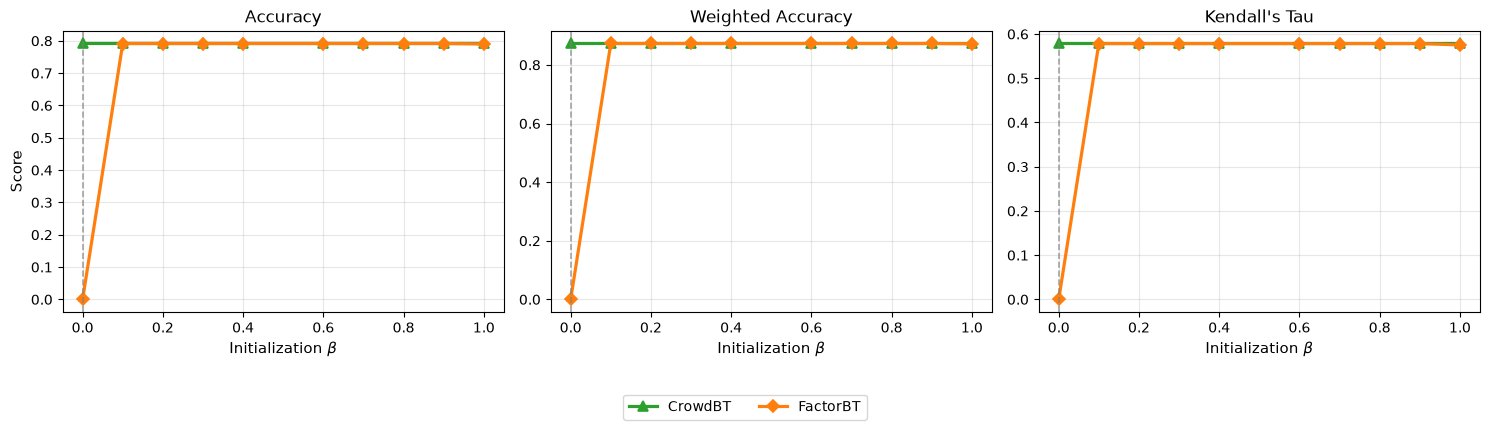

In [1]:
import json
import os
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# Input files and model names
# -----------------------------------------------------------------------------

file_mapping = {
    "ablation_results_pgem_hbtl.json": ["pgem", "hbtl"],
    "ablation_results_crowdbt.json": ["crowdbt"],
    "ablation_results_noisybt.json": ["noisybt"],
}

# -----------------------------------------------------------------------------
# Plot styles
# -----------------------------------------------------------------------------

styles = {
    "pgem": dict(color="#e62e73", marker="o"),
    "hbtl": dict(color="#1f4e79", marker="s"),
    "crowdbt": dict(color="#2ca02c", marker="^"),
    "noisybt": dict(color="#ff7f0e", marker="D"),
}

display_names = {
    "pgem": "BoRaEM (ours)",
    "hbtl": "HBTL",
    "crowdbt": "CrowdBT",
    "noisybt": "FactorBT",
}

metrics_keys = ["acc", "wacc", "tau"]
titles = ["Accuracy", "Weighted Accuracy", "Kendall's Tau"]

# -----------------------------------------------------------------------------
# Read JSON files
# -----------------------------------------------------------------------------

data_to_plot = {}

for filename, models in file_mapping.items():

    if not os.path.exists(filename):
        print(f"Skipping {filename}")
        continue

    with open(filename, "r") as f:
        file_data = json.load(f)

    # normalize JSON keys to lowercase
    file_data = {k.lower(): v for k, v in file_data.items()}

    for model in models:

        if model not in file_data:
            print(f"{model} not found in {filename}")
            continue

        model_dict = file_data[model]

        # normalize beta keys once
        normalized = {float(k): v for k, v in model_dict.items()}

        betas = []
        acc = []
        wacc = []
        tau = []

        for beta in sorted(normalized):

            # Skip undesired beta values
            if model in ("pgem", "hbtl") and beta == 0.0:
                continue

            if model in ("crowdbt", "noisybt") and beta == 0.5:
                continue

            metrics = normalized[beta]

            betas.append(beta)
            acc.append(metrics[0])
            wacc.append(metrics[1])
            tau.append(metrics[2])

        data_to_plot[model] = {
            "betas": betas,
            "acc": acc,
            "wacc": wacc,
            "tau": tau,
        }

# -----------------------------------------------------------------------------
# Plotting function
# -----------------------------------------------------------------------------

def create_chart(models, outfile):

    outdir = os.path.dirname(outfile)
    if outdir:
        os.makedirs(outdir, exist_ok=True)

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 4.2),
        sharey=False,
    )

    # collect all beta values for reference line
    all_betas = []
    for m in models:
        if m in data_to_plot:
            all_betas.extend(data_to_plot[m]["betas"])

    for ax, metric, title in zip(axes, metrics_keys, titles):

        for model in models:

            if model not in data_to_plot:
                continue

            ax.plot(
                data_to_plot[model]["betas"],
                data_to_plot[model][metric],
                label=display_names[model],
                color=styles[model]["color"],
                marker=styles[model]["marker"],
                linewidth=2.3,
                markersize=6.5,
                markeredgewidth=1.2,
            )

        ax.set_title(title, fontsize=12)
        ax.set_xlabel(r"Initialization $\beta$", fontsize=11)

        if metric == "acc":
            ax.set_ylabel("Score", fontsize=11)

        ax.grid(True, alpha=0.3)

        if all_betas and min(all_betas) <= 0 <= max(all_betas):
            ax.axvline(
                0,
                color="gray",
                linestyle="--",
                linewidth=1.2,
                alpha=0.7,
            )

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.03),
        ncol=len(models),
        frameon=True,
        fontsize=10,
    )

    fig.tight_layout(rect=[0, 0.10, 1, 1])

    plt.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


# -----------------------------------------------------------------------------
# Generate figures
# -----------------------------------------------------------------------------

create_chart(
    ["pgem", "hbtl"],
    "figures/ablation_pgem_hbtl.pdf",
)

create_chart(
    ["crowdbt", "noisybt"],
    "figures/ablation_crowdbt_factorbt.pdf",
)

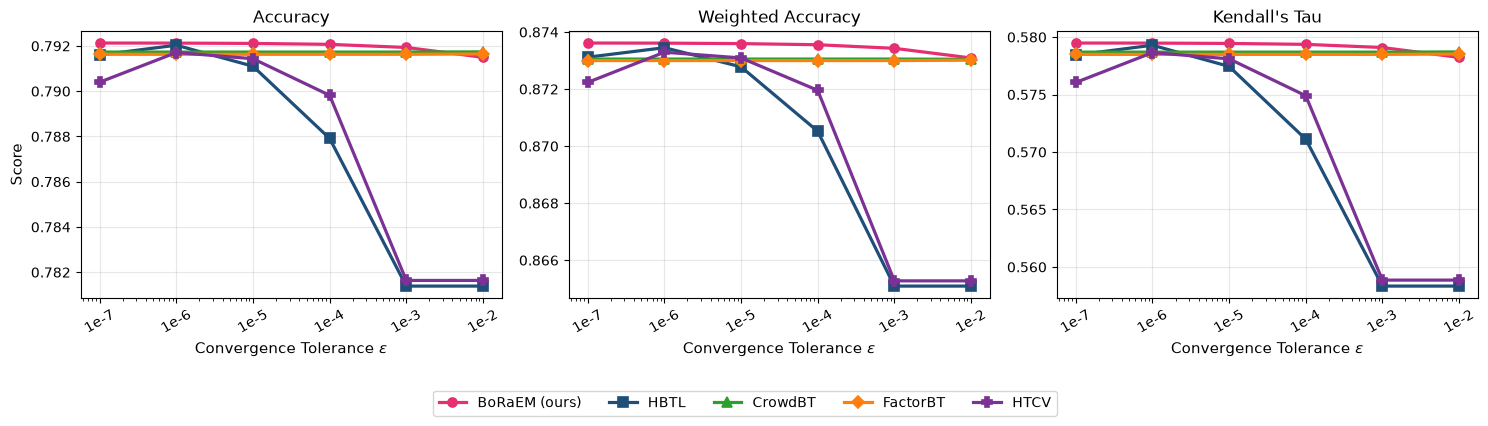

In [2]:
import json
import os
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# Input files and model names
# -----------------------------------------------------------------------------

file_mapping = {
    "ablation_results_epsilon.json": ["pgem", "hbtl", "crowdbt", "noisybt"],
    "ablation_results_epsilon_htcv.json": ["htcv"],
}

# -----------------------------------------------------------------------------
# Plot styles
# -----------------------------------------------------------------------------

styles = {
    "pgem": dict(color="#e62e73", marker="o"),
    "hbtl": dict(color="#1f4e79", marker="s"),
    "crowdbt": dict(color="#2ca02c", marker="^"),
    "noisybt": dict(color="#ff7f0e", marker="D"),
    "htcv": dict(color="#7b3294", marker="P"),
}

display_names = {
    "pgem": "BoRaEM (ours)",
    "hbtl": "HBTL",
    "crowdbt": "CrowdBT",
    "noisybt": "FactorBT",
    "htcv": "HTCV",
}

metrics_keys = ["acc", "wacc", "tau"]
titles = ["Accuracy", "Weighted Accuracy", "Kendall's Tau"]

# -----------------------------------------------------------------------------
# Read JSON files
# -----------------------------------------------------------------------------

data_to_plot = {}

for filename, models in file_mapping.items():

    if not os.path.exists(filename):
        print(f"Skipping {filename}")
        continue

    with open(filename, "r") as f:
        file_data = json.load(f)

    file_data = {k.lower(): v for k, v in file_data.items()}

    for model in models:

        if model not in file_data:
            print(f"{model} not found in {filename}")
            continue

        model_dict = file_data[model]

        normalized = {float(k): v for k, v in model_dict.items()}

        epsilons = []
        acc = []
        wacc = []
        tau = []

        for eps in sorted(normalized):

            metrics = normalized[eps]

            epsilons.append(eps)
            acc.append(metrics[0])
            wacc.append(metrics[1])
            tau.append(metrics[2])

        data_to_plot[model] = {
            "epsilons": epsilons,
            "acc": acc,
            "wacc": wacc,
            "tau": tau,
        }

# -----------------------------------------------------------------------------
# Plotting function
# -----------------------------------------------------------------------------

def create_chart(models, outfile):

    outdir = os.path.dirname(outfile)
    if outdir:
        os.makedirs(outdir, exist_ok=True)

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 4.2),
        sharey=False,
    )

    for ax, metric, title in zip(axes, metrics_keys, titles):

        for model in models:

            if model not in data_to_plot:
                continue

            ax.plot(
                data_to_plot[model]["epsilons"],
                data_to_plot[model][metric],
                label=display_names[model],
                color=styles[model]["color"],
                marker=styles[model]["marker"],
                linewidth=2.3,
                markersize=6.5,
                markeredgewidth=1.2,
            )

        ax.set_title(title, fontsize=12)
        ax.set_xlabel(r"Convergence Tolerance $\epsilon$", fontsize=11)

        if metric == "acc":
            ax.set_ylabel("Score", fontsize=11)

        ax.grid(True, alpha=0.3)
        ax.set_xscale("log")

        ticks = [1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
        ax.set_xticks(ticks)
        ax.set_xticklabels(
            ["1e-7", "1e-6", "1e-5",
             "1e-4", "1e-3", "1e-2"],
            rotation=30,
        )

    # Common legend for the entire figure
    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.02),
        ncol=5,          # one column per method
        frameon=True,
        fontsize=10,
    )

    fig.tight_layout(rect=[0, 0.10, 1, 1])

    plt.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

# -----------------------------------------------------------------------------
# Generate figure
# -----------------------------------------------------------------------------

create_chart(
    ["pgem", "hbtl", "crowdbt", "noisybt", "htcv"],
    "figures/ablation_epsilon.pdf",
)